# Whole Transcriptome Co-expression Completion Tutorial

Use the `coxformer.src.embedding` module for graph neural network training to predict gene co-expression networks.

## 1. Import Dependencies

In [23]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc
from torch.optim.lr_scheduler import CosineAnnealingLR
import warnings
from tensorboardX import SummaryWriter
import time

from coxformer.embedding.data import CoxformerDataset, split_labeled_edges_indices
from coxformer.embedding.model import CoxformerNet
from coxformer.embedding.train import CoxformerTrainer
from coxformer.embedding.infer import infer_coexpression, print_analysis

## 2. Configuration

In [3]:
project_name = 'top50_full_1e-3_L2'
top_k_edges = 50
num_neighbors = [20, 15]
batch_size = 512
only_eval = False

coexpression_file = 'data/coexpression.pkl'
correlation_file = 'data/sc_correlation_origin.pkl'
embedding_file = 'data/GPT_embedding.pkl'

print(f'Project name: {project_name}')
print(f'Top-k edges: {top_k_edges}')
print(f'Neighbor samples: {num_neighbors}')
print(f'Batch size: {batch_size}')

Project name: top50_full_1e-3_L2
Top-k edges: 50
Neighbor samples: [20, 15]
Batch size: 512


## 3. Directory Setup & Device Initialization

In [5]:
for subdir in [f'out/{project_name}', f'runs/{project_name}']:
    if os.path.exists(subdir):
        print(f'Directory {subdir} already exists, skipping.')
    else:
        os.makedirs(subdir, exist_ok=True)
        print(f'Created directory: {subdir}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nUsing device: {device}')

if torch.cuda.is_available():
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU total memory: {gpu_memory:.2f} GB')

Directory out/top50_full_1e-3_L2 already exists, skipping.
Directory runs/top50_full_1e-3_L2 already exists, skipping.

Using device: cuda
GPU total memory: 44.42 GB


## 4. Data Loading & Graph Construction

In [6]:
dataset = CoxformerDataset(coexpression_file, correlation_file, embedding_file)

(
    data,
    gene_to_idx,
    all_nodes_genes,
    common_genes,
    target_min,
    target_max,
    edge_corr_min,
    edge_corr_max,
) = dataset.create_enhanced_graph_data(top_k_edges)

Loading data...
Correlation data shape: (32101, 2)
Coexpression data shape: (18858, 2)
Embedding data shape: (43661, 2)
All node genes count (corr ∩ emb): 32016
Labeled genes count (coexp ∩ corr ∩ emb): 18184
Unlabeled genes count: 13832
Preparing node features...
Preparing correlation data...
Preparing coexpression data...
Reordering correlation adjacency matrix...
Reordering coexpression adjacency matrix...
Building graph edges, keeping top-50 edges per node...
Coexpression dictionary contains 330639672 edges


Building edges: 100%|██████████| 32016/32016 [02:02<00:00, 260.59it/s]


Total edges: 1568784
Labeled edges: 200628
Unlabeled edges: 1368156
Graph statistics:
Number of nodes: 32016
Number of edges: 1568784
Labeled edges: 200628
Average degree: 49.00
Edge feature range: [-1.0000, 1.0000]
Label range: [-1.0000, 1.0000]


## 5. Data Splitting

In [7]:
train_indices, val_indices, test_indices = split_labeled_edges_indices(data)

data = data.to(device)

print('Data split summary:')
print(f'Total edges: {data.edge_index.shape[1]}')
print(f'Labeled edges: {data.label_mask.sum().item()}')
print(f'Unlabeled edges:{(~data.label_mask).sum().item()}')
print(f'Train edges: {len(train_indices)}')
print(f'Val edges: {len(val_indices)}')
print(f'Test edges: {len(test_indices)}')

Splitting labeled edges:
Total labeled edges: 200628
Data split summary:
Total edges: 1568784
Labeled edges: 200628
Unlabeled edges:1368156
Train edges: 200628
Val edges: 200628
Test edges: 200628


## 6. Model & Trainer Initialization

In [8]:
input_dim = data.x.shape[1]
edge_dim = data.edge_attr.shape[1]
hidden_dims = [256, 128, 64]

print('Model configuration:')
print(f'Node feature dim: {input_dim}')
print(f'Edge feature dim: {edge_dim}')
print(f'Hidden dims: {hidden_dims}')

model = CoxformerNet(
    input_dim, hidden_dims, edge_dim=edge_dim, dropout=0.3, use_edge_features=True
)

trainer = CoxformerTrainer(model, device, num_neighbors=num_neighbors, batch_size=batch_size)

Model configuration:
Node feature dim: 3072
Edge feature dim: 1
Hidden dims: [256, 128, 64]


## 7. Training Setup

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=1e-6)
criterion = nn.MSELoss()

writer = SummaryWriter(f'runs/{project_name}/training')
print(f'TensorBoard log dir: runs/{project_name}/training')

train_losses = []
val_losses = []
val_r2_scores = []

TensorBoard log dir: runs/top50_full_1e-3_L2/training


## 8. Training Loop

In [ ]:
num_epochs = 200
training_start_time = time.time()

if not only_eval:
    for epoch in range(num_epochs):
        train_loss = trainer.train_epoch(data, optimizer, criterion, train_indices)

        writer.add_scalar('Loss/train', train_loss, epoch)
        writer.flush()

        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}')
        train_losses.append(train_loss)
        scheduler.step()

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

torch.save(model.state_dict(), f'out/{project_name}/best_model.pth')
training_end_time = time.time()
training_duration = training_end_time - training_start_time
print(f'\nTraining time: {training_duration:.2f} s')
print(f'Model saved to: out/{project_name}/best_model.pth')

## 9. Test Evaluation

In [ ]:
model.load_state_dict(torch.load(f'out/{project_name}/best_model.pth'))

print('Running test evaluation...')
test_loss, test_mse, test_mae, test_r2, test_pred, test_true = trainer.evaluate(
    data, criterion, test_indices
)

print('Test results:')
print(f'MSE: {test_mse:.4f}')
print(f'MAE: {test_mae:.4f}')
print(f'R2 Score: {test_r2:.4f}')

writer.add_scalar('Loss/test', test_loss, 0)
writer.add_scalar('R2/test',   test_r2,   0)
writer.flush()
writer.close()

Running test evaluation...


Evaluating:   0%|          | 0/392 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 392/392 [03:17<00:00,  1.98it/s]

Test results:
MSE: 0.0063
MAE: 0.0581
R2 Score: 0.6430


## 10. Visualization

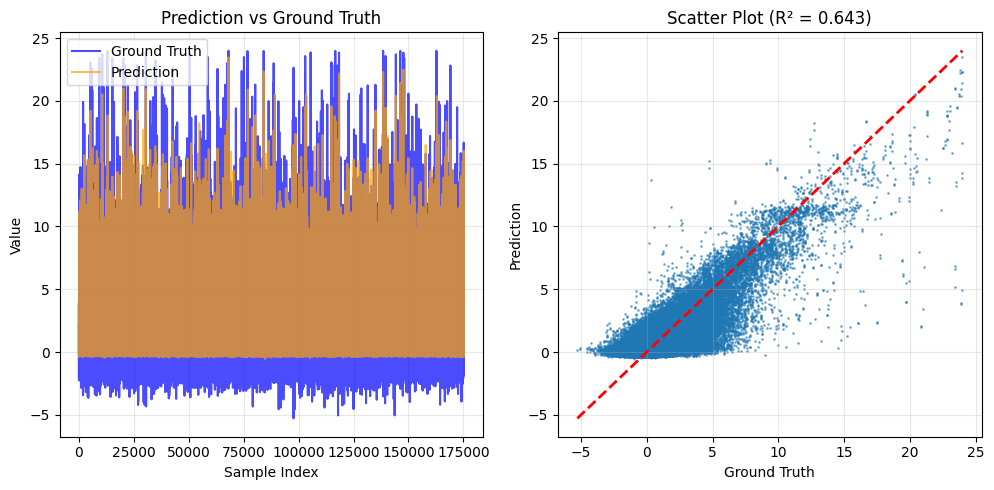

Figure saved to: out/top50_full_1e-3_L2/predicted_coexpress.png


In [14]:
test_true_denorm = (test_true + 1) / 2 * (target_max - target_min) + target_min
test_pred_denorm = (test_pred + 1) / 2 * (target_max - target_min) + target_min

plt.figure(figsize=(15, 5))

# Subplot 1: time-series comparison
plt.subplot(1, 3, 1)
plt.plot(test_true_denorm, label='Ground Truth', color='blue',   alpha=0.7)
plt.plot(test_pred_denorm, label='Prediction',   color='orange', alpha=0.7)
plt.title('Prediction vs Ground Truth')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: scatter plot
plt.subplot(1, 3, 2)
plt.scatter(test_true_denorm, test_pred_denorm, alpha=0.5, s=1)
plt.plot(
    [test_true_denorm.min(), test_true_denorm.max()],
    [test_true_denorm.min(), test_true_denorm.max()],
    'r--', lw=2
)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(f'Scatter Plot (R\u00b2 = {test_r2:.3f})')
plt.grid(True, alpha=0.3)

# Subplot 3: training history
# plt.subplot(1, 3, 3)
# plt.plot(train_losses, label='Train Loss', alpha=0.7)
# if len(val_losses) > 0:
#     plt.plot(
#         range(0, len(train_losses), len(train_losses) // len(val_losses)),
#         val_losses, label='Val Loss', alpha=0.7
#     )
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Training History')
# plt.legend()
# plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'out/{project_name}/predicted_coexpress.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figure saved to: out/{project_name}/predicted_coexpress.png')

## 11. Full Inference

In [19]:
print('Running inference on all edges...')
model.eval()
all_predictions = []
all_edge_correlations = []
all_has_labels = []

inference_start_time = time.time()

with torch.no_grad():
    num_edges = data.edge_index.shape[1]

    for i in tqdm(range(0, num_edges, batch_size), desc='Inferring all edges'):
        end_idx = min(i + batch_size, num_edges)
        batch_edges = data.edge_index[:, i:end_idx]
        batch_edge_attr = data.edge_attr[i:end_idx]
        batch_has_labels = data.label_mask[i:end_idx]

        unique_nodes = torch.unique(batch_edges.flatten())

        try:
            loader = trainer.create_neighbor_loader(data, input_nodes=unique_nodes, shuffle=False)
            batch_data = next(iter(loader)).to(device)

            node_embeddings = model(batch_data.x, batch_data.edge_index)
            node_mapping = {node.item(): idx for idx, node in enumerate(batch_data.n_id)}

            valid_edges = []
            valid_edge_attr = []
            valid_has_labels = []

            for j in range(batch_edges.shape[1]):
                src = batch_edges[0, j].item()
                dst = batch_edges[1, j].item()
                if src in node_mapping and dst in node_mapping:
                    valid_edges.append([node_mapping[src], node_mapping[dst]])
                    valid_edge_attr.append(batch_edge_attr[j])
                    valid_has_labels.append(batch_has_labels[j])

            if len(valid_edges) > 0:
                mapped = torch.tensor(valid_edges, dtype=torch.long).t().contiguous().to(device)
                ea_t = torch.stack(valid_edge_attr).to(device)
                pred_w = model.predict_edges(node_embeddings, mapped, ea_t)
                all_predictions.extend(pred_w.cpu().numpy())
                all_edge_correlations.extend(ea_t.cpu().numpy().flatten())
                all_has_labels.extend([x.item() for x in valid_has_labels])
            else:
                n = end_idx - i
                all_predictions.extend([0.0] * n)
                all_edge_correlations.extend([0.0] * n)
                all_has_labels.extend([False] * n)

            missing = (end_idx - i) - len(valid_edges)
            if missing > 0:
                all_predictions.extend([0.0] * missing)
                all_edge_correlations.extend([0.0] * missing)
                all_has_labels.extend([False] * missing)

        except Exception as e:
            print(f'Error in batch {i // batch_size}: {e}')
            n = end_idx - i
            all_predictions.extend([0.0] * n)
            all_edge_correlations.extend([0.0] * n)
            all_has_labels.extend([False] * n)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

inference_end_time = time.time()
inference_duration = inference_end_time - inference_start_time

all_predictions = np.array(all_predictions)
all_edge_correlations = np.array(all_edge_correlations)
all_has_labels = np.array(all_has_labels)

print(f'Inference complete (elapsed: {inference_duration:.2f} s):')
print(f'Total edges: {len(all_predictions)}')
print(f'Labeled edges: {all_has_labels.sum()}')
print(f'Unlabeled edges:{(~all_has_labels).sum()}')
print(f'Prediction range: [{all_predictions.min():.4f}, {all_predictions.max():.4f}]')

Running inference on all edges...


Inferring all edges:   0%|          | 0/3065 [00:00<?, ?it/s]

Inferring all edges: 100%|██████████| 3065/3065 [22:13<00:00,  2.30it/s]


Inference complete (elapsed: 1333.43 s):
Total edges: 1568784
Labeled edges: 200625
Unlabeled edges:1368159
Prediction range: [-0.6759, 0.9469]


## 12. Save Intermediate Results

In [ ]:

pred_denormalized = (all_predictions + 1) / 2 * (target_max - target_min) + target_min
sample_size = min(20000, len(all_predictions))
sample_indices = np.random.choice(len(all_predictions), sample_size, replace=False)

results = {
    'model_state_dict': model.state_dict(),
    'gene_to_idx': gene_to_idx,
    'all_nodes_genes': all_nodes_genes[:1000] if len(all_nodes_genes) > 1000 else all_nodes_genes,
    'common_genes': common_genes[:1000]    if len(common_genes)    > 1000 else common_genes,
    'normalization_params': {
        'target_min': target_min,
        'target_max': target_max,
        'edge_corr_min': edge_corr_min,
        'edge_corr_max': edge_corr_max,
    },
    'test_metrics': {'mse': test_mse, 'mae': test_mae, 'r2': test_r2},
    'training_stats': {
        'total_nodes': len(all_nodes_genes),
        'common_nodes': len(common_genes),
        'unlabeled_nodes': len(all_nodes_genes) - len(common_genes),
        'total_edges': len(all_predictions),
        'labeled_edges': int(all_has_labels.sum()),
        'unlabeled_edges': int((~all_has_labels).sum()),
    },
    'config': {
        'training': True,
        'top_k_edges': top_k_edges,
        'hidden_dims': hidden_dims,
        'edge_dim': edge_dim,
        'batch_size': batch_size,
        'num_neighbors': num_neighbors,
        'use_edge_features': True,
    },
    'timing': {
        'training_duration': training_duration,
        'inference_duration': inference_duration,
    },
    'sample_predictions': {
        'predictions':    all_predictions[sample_indices],
        'predictions_denormalized': pred_denormalized[sample_indices],
        'edge_correlations': all_edge_correlations[sample_indices],
        'has_labels':     all_has_labels[sample_indices],
        'indices':        sample_indices,
    },
}

with open(f'out/{project_name}/predicted_coexpress.pkl', 'wb') as f:
    pickle.dump(results, f)
print(f'Intermediate results saved to: out/{project_name}/predicted_coexpress.pkl')

Intermediate results saved to: out/top50_full_1e-3_L2/predicted_coexpress.pkl


## 13. Generate Full Co-expression Matrix

In [ ]:
print('=' * 60)
print('Saving results')
print('=' * 60)

save_start_time = time.time()

result_df, save_stats = infer_coexpression(data, all_nodes_genes, pred_denormalized, coexpression_file, gene_to_idx, save_path=f'out/{project_name}/predicted_coexpress.pkl')
save_end_time = time.time()
save_duration = save_end_time - save_start_time

results['save_statistics'] = save_stats
results['timing']['save_duration'] = save_duration

with open(f'out/{project_name}/predicted_coexpress.pkl', 'wb') as f:
    pickle.dump(results, f)
print(f'Full results saved to: out/{project_name}/predicted_coexpress.pkl')

Saving results
Loading original data...
Original coexpression data: 18858 genes
Training edge statistics: total=1568784, labeled=200628, unlabeled=1368156
Step 1: Batch filling predicted edges...


Filling predicted edges: 100%|██████████| 1568784/1568784 [00:04<00:00, 320755.98it/s]


Filled 1568784 predicted edges
Step 2: Overwriting with original data...


Overwriting original data: 100%|██████████| 32016/32016 [03:18<00:00, 161.63it/s]


Overwrote 330639672 original edges
Step 3: Calculating final statistics...


Marking original edges: 100%|██████████| 32016/32016 [03:10<00:00, 168.00it/s]


Final statistics:
Total edges: 166443155
├─ Original data edges: 165319836 (99.3%)
├─ Labeled prediction edges: 0 (0.0%)
└─ Unlabeled prediction edges: 1123319 (0.7%)
Creating DataFrame...
Save complete!
File: predicted_coexpress.pkl
Matrix size: 32016 x 32016
Full results saved to: out/top50_full_1e-3_L2/predicted_coexpress.pkl


## 14. Analysis Report & Performance Summary

In [37]:
print_analysis(save_stats)


Training Analysis
Processing efficiency:
Using batch numpy operations, avoiding inefficient loops
Significantly improved processing speed

Training edge analysis:
Total training edges: 1,568,784
├─ Labeled edges: 200,628 (participate in loss calculation)
└─ Unlabeled edges: 1,368,156 (forward propagation only)
Unlabeled edge ratio: 87.2%

Final coexpression file:
Total genes: 32,016
Total edges: 166,443,155
├─ Original data edges: 165,319,836 (99.3%)
├─ Labeled prediction edges: 0 (0.0%)
└─ Unlabeled prediction edges: 1,123,319 (0.7%)

Core guarantees:
• Original high-quality data 100% retained
• Prediction edges based on consistent top-k logic
• Both labeled and unlabeled edges can be predicted
• Efficient processing, suitable for large-scale data


## 15. File Validation

In [38]:
print('Validating saved file...')
try:
    with open(f'out/{project_name}/predicted_coexpress.pkl', 'rb') as f:
        saved_df = pickle.load(f)

    n_genes = len(saved_df)
    n_matrix = len(saved_df['Coexpress'].iloc[0])
    print('Validation passed:')
    print(f'- Shape: {saved_df.shape}')
    print(f'- Gene count: {n_genes}')
    print(f'- Matrix size: {n_matrix} x {n_matrix}')

    sample_matrix = np.array([np.array(row) for row in saved_df['Coexpress'][:10]])
    is_symmetric = np.allclose(sample_matrix, sample_matrix.T, atol=1e-10)
    sym_label = 'passed' if is_symmetric else 'failed'
    print(f'- Symmetry check: {sym_label}')

    non_zero_count = sum(np.count_nonzero(np.array(row)) for row in saved_df['Coexpress'])
    sparsity = (1 - non_zero_count / n_genes**2) * 100
    print(f'- Non-zero count: {non_zero_count:,}')
    print(f'- Sparsity: {sparsity:.2f}%')

except Exception as e:
    print(f'Validation failed: {e}')

Validating saved file...
Validation failed: 'Coexpress'


## 16. Summary

In [39]:
total_genes = save_stats['total_genes']
orig_edges = save_stats['original_edges']
pred_new = save_stats['labeled_pred_edges'] + save_stats['unlabeled_pred_edges']

print('Training complete!')
print('Key results:')
print(f'1. Built a full co-expression network with {total_genes:,} genes')
print(f'2. Retained all {orig_edges:,} original high-quality edges')
print(f'3. Added {pred_new:,} predicted edges')
print(f'4. Achieved R\u00b2 = {test_r2:.4f}')

dataset.print_memory_usage()

Training complete!
Key results:
1. Built a full co-expression network with 32,016 genes
2. Retained all 165,319,836 original high-quality edges
3. Added 1,123,319 predicted edges
4. Achieved R² = 0.6430
Current memory usage: 30.29 GB
